# MaskedDALLEVAE — Reconstruction Demo

Loads `checkpoints/best_model.pt` and demonstrates reconstruction from a partially-masked latent grid.

For each sample we show three panels:

1. **Original** — the input image after resize/center-crop to 256×256.
2. **Masked** — the same image with the 8×8 pixel blocks corresponding to masked 32×32 latent positions blanked out (this is a pixel-space *visualization* of where the decoder will be receiving the learned `MASK_TOKEN` distribution instead of the encoder's codewords).
3. **Reconstructed** — a composite: original pixels are kept in the unmasked 8×8 patches, and the decoder's output (mean of the logit-Laplace distribution, mapped back to `[0, 1]`) fills in only the masked patches. This isolates what the model actually has to hallucinate from the MASK_TOKEN signal.

In [15]:
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms

from dall_e import load_model, map_pixels, unmap_pixels

# Make the project's `MaskedDALLEVAE` class importable
import sys
sys.path.insert(0, str(Path.cwd()))
from finetune_mask_vae import (
    MaskedDALLEVAE,
    IMAGE_SIZE,
    LATENT_SIZE,
    FlatImageDataset,
    _build_transform,
    _find_split_dir,
    DATASET_ROOT,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. Load pretrained encoder/decoder and the fine-tuned checkpoint

In [16]:
ENCODER_PATH = "encoder.pkl"
DECODER_PATH = "decoder.pkl"
CKPT_PATH    = "checkpoints/best_model.pt"

encoder = load_model(ENCODER_PATH, device=device)
decoder = load_model(DECODER_PATH, device=device)

ckpt = torch.load(CKPT_PATH, map_location=device)
mask_tok_id = ckpt.get("mask_token_id", 0)

model = MaskedDALLEVAE(encoder, decoder, mask_token_id=mask_tok_id)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device).eval()

print(f"Checkpoint epoch    : {ckpt.get('epoch', '?')}")
print(f"Best val NLL        : {ckpt.get('val_nll', '?')}")
print(f"MASK_TOKEN slot id  : {mask_tok_id}")
print(f"Training mask_ratio : {ckpt.get('args', {}).get('mask_ratio', '?')}")

Checkpoint epoch    : 2
Best val NLL        : -2.376366
MASK_TOKEN slot id  : 3
Training mask_ratio : 0.5


## 2. Pick a few test images

In [17]:
# Try `test` first, fall back to `validation`, then `train`.
for split in ("test", "validation", "train"):
    split_root = _find_split_dir(DATASET_ROOT, split)
    if split_root.exists() and any(split_root.rglob("*")):
        break

ds = FlatImageDataset(split_root, transform=_build_transform())
print(f"Split used : {split}")
print(f"Root       : {split_root}")
print(f"Images     : {len(ds):,}")

N_SAMPLES = 6
rng = np.random.default_rng(seed=0)
indices = rng.choice(len(ds), size=N_SAMPLES, replace=False).tolist()

batch_list = [ds[i] for i in indices]
batch_list = [t for t in batch_list if t is not None]
batch      = torch.stack(batch_list).to(device)
print("batch:", tuple(batch.shape))

Split used : test
Root       : E:\OpenImageV7\test
Images     : 125,436
batch: (6, 3, 256, 256)


## 3. Forward in three explicit stages: encode → mask → decode

The `MaskedDALLEVAE.forward` method runs all three steps in one go, but for evaluation it's clearer to call them separately so each intermediate tensor is visible:

1. **Encode** — `model.encode_logits(x)` produces 8192-way logits at the 32×32 latent grid. Softmax converts these to soft one-hot codeword distributions.
2. **Mask** — pick a random subset of latent positions and replace their soft one-hot with `softmax(model.mask_token)` (the learned MASK_TOKEN distribution).
3. **Decode** — feed the (partially masked) soft one-hot tensor to the decoder to get the logit-Laplace parameters, then convert the mean back to pixel space.

In [ ]:
MASK_RATIO = ckpt.get("args", {}).get("mask_ratio", 0.5)
torch.manual_seed(0)  # reproducible mask layout

with torch.no_grad():
    x_mapped = map_pixels(batch)                                  # in (eps, 1-eps)

    # ── Stage 1: encode ──────────────────────────────────────────────────
    logits = model.encode_logits(x_mapped)                        # [B,V,h,w]
    soft   = model.logits_to_soft(logits)                         # [B,V,h,w]
    B, V, h, w = soft.shape

    # ── Stage 2: mask in latent space ────────────────────────────────────
    mask    = model._make_random_mask(B, h, w, MASK_RATIO, batch.device)
    soft_in = model.apply_mask(soft, mask)                        # [B,V,h,w]

    # ── Stage 3: decode ──────────────────────────────────────────────────
    recon_params = model.decoder(soft_in.float())                 # [B,6,H,W]
    mu_mapped    = torch.sigmoid(recon_params[:, :3].float())
    recon_pix    = unmap_pixels(mu_mapped).clamp(0.0, 1.0)        # [B,3,H,W]

print(f"logits     : {tuple(logits.shape)}")
print(f"soft       : {tuple(soft.shape)}  (sums to 1 along V: "
      f"{soft.sum(dim=1).mean().item():.3f})")
print(f"mask       : {tuple(mask.shape)}  — True positions masked")
print(f"soft_in    : {tuple(soft_in.shape)}  (after MASK_TOKEN substitution)")
print(f"recon_pix  : {tuple(recon_pix.shape)}")
print(f"fraction masked (this batch): {mask.float().mean().item():.3f}")

## 4. Build the pixel-space masked-image visualization and the composite reconstruction

Each of the 32×32 latent positions corresponds to an 8×8 pixel patch. Upsample the boolean latent mask by ×8 (nearest-neighbor) to get a 256×256 pixel mask. Then:

- `masked_vis` — blank the masked patches on the **original** to mid-gray, for the "masked" panel.
- `recon_composite` — keep the **original** pixels in unmasked patches and paste the **decoder output** only into masked patches. This is what we display as "reconstructed".

In [19]:
PATCH = IMAGE_SIZE // LATENT_SIZE   # 8

# [B, 1, 32, 32] → [B, 1, 256, 256]
pixel_mask = mask.unsqueeze(1).float()
pixel_mask = F.interpolate(pixel_mask, scale_factor=PATCH, mode="nearest")
pixel_mask_b = pixel_mask.bool().expand_as(batch)

GRAY = 0.5
masked_vis = torch.where(pixel_mask_b,
                          torch.full_like(batch, GRAY),
                          batch)

# Composite: original pixels in unmasked patches, decoder output in masked patches.
recon_composite = torch.where(pixel_mask_b, recon_pix, batch)

## 5. Plot original / masked / reconstructed

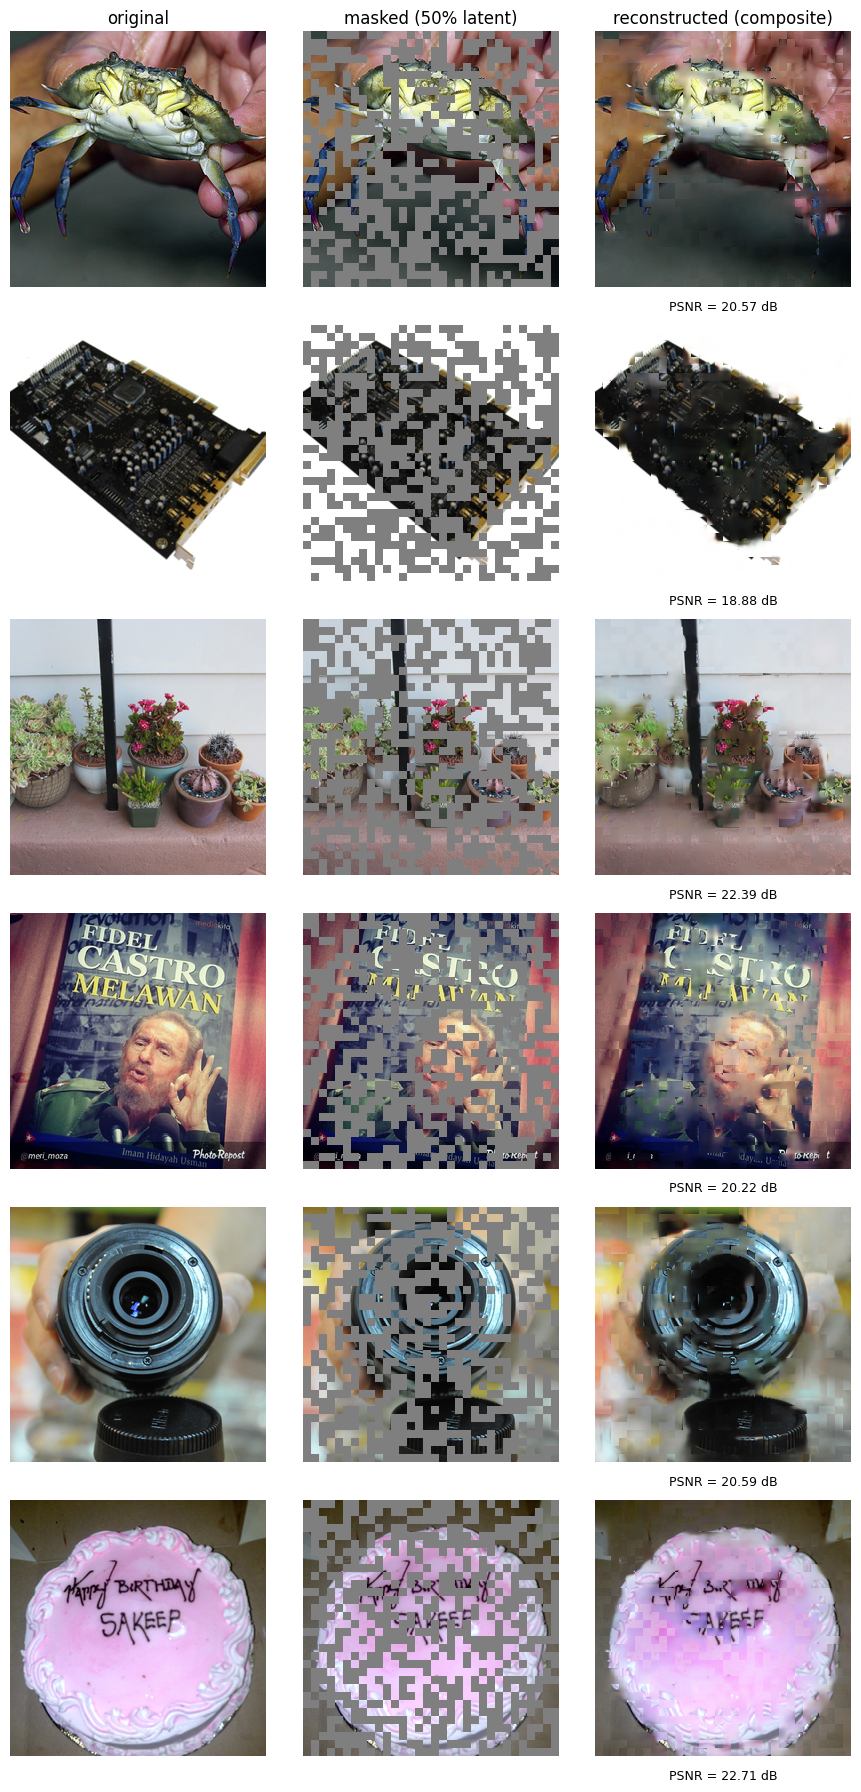

In [20]:
def to_np(img: torch.Tensor) -> np.ndarray:
    """[3,H,W] in [0,1] → [H,W,3] uint8-friendly float."""
    return img.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()

def psnr(a: torch.Tensor, b: torch.Tensor) -> float:
    mse = F.mse_loss(a.float(), b.float()).item()
    return 10.0 * np.log10(1.0 / (mse + 1e-10))

n = batch.size(0)
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
if n == 1:
    axes = axes[None, :]

for i in range(n):
    # PSNR of the composite vs. original — unmasked patches are pixel-identical,
    # so this score reflects only the model's fill quality, weighted by mask area.
    p = psnr(recon_composite[i], batch[i])

    axes[i, 0].imshow(to_np(batch[i]))
    axes[i, 0].set_title("original" if i == 0 else "")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(to_np(masked_vis[i]))
    axes[i, 1].set_title(f"masked ({MASK_RATIO:.0%} latent)" if i == 0 else "")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(to_np(recon_composite[i]))
    axes[i, 2].set_title("reconstructed (composite)" if i == 0 else "")
    axes[i, 2].set_xticks([]); axes[i, 2].set_yticks([])
    for spine in axes[i, 2].spines.values():
        spine.set_visible(False)
    axes[i, 2].text(0.5, -0.05, f"PSNR = {p:.2f} dB",
                    transform=axes[i, 2].transAxes,
                    ha="center", va="top", fontsize=9)

plt.tight_layout()
plt.show()

## 6. (Optional) Sweep over mask ratios on a single image

See how reconstruction quality degrades as more latent positions are masked.

In [ ]:
RATIOS = [0.0, 0.25, 0.5, 0.75, 0.9]
src = batch[:1]                                    # single image, keep batch dim
src_mapped = map_pixels(src)

# Encode ONCE — the encoder output is independent of mask_ratio.
with torch.no_grad():
    src_logits = model.encode_logits(src_mapped)
    src_soft   = model.logits_to_soft(src_logits)
B, V, h, w = src_soft.shape

fig, axes = plt.subplots(2, len(RATIOS), figsize=(3 * len(RATIOS), 6))

for col, r in enumerate(RATIOS):
    torch.manual_seed(0)
    with torch.no_grad():
        # Mask stage
        m       = model._make_random_mask(B, h, w, r, src.device)
        soft_in = model.apply_mask(src_soft, m) if r > 0 else src_soft

        # Decode stage
        rp    = model.decoder(soft_in.float())
        recon = unmap_pixels(torch.sigmoid(rp[:, :3].float())).clamp(0, 1)

    # build pixel-space mask, then the masked-input vis and composite recon
    pm = F.interpolate(m.unsqueeze(1).float(), scale_factor=PATCH, mode="nearest")
    pm_b = pm.bool().expand_as(src)

    vis       = torch.where(pm_b, torch.full_like(src, GRAY), src)
    composite = torch.where(pm_b, recon, src)

    p = psnr(composite[0], src[0])

    axes[0, col].imshow(to_np(vis[0]))
    axes[0, col].set_title(f"mask {r:.0%}")
    axes[0, col].axis("off")

    axes[1, col].imshow(to_np(composite[0]))
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
    for spine in axes[1, col].spines.values():
        spine.set_visible(False)
    axes[1, col].text(0.5, -0.05, f"PSNR {p:.2f} dB",
                      transform=axes[1, col].transAxes,
                      ha="center", va="top", fontsize=9)

axes[0, 0].set_ylabel("masked input", fontsize=10)
axes[1, 0].set_ylabel("reconstruction (composite)", fontsize=10)
plt.tight_layout()
plt.show()